In [1]:
import cooler
import numpy as np
import pandas as pd
from scipy.sparse import triu
from scipy.stats import pearsonr, zscore, norm
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor, as_completed
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib import cm as cm
import seaborn as sns
from glob import glob
from skimage.transform import resize

mpl.style.use('default')
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = 'Helvetica'


/home/ivorytowerdds/.local/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
indir = '/large_storage/zhoulab/zhoujt/project/seqmodel/241009_hicloop/'

In [3]:
test_chrom = ['chr15']

In [4]:
diffloop = pd.read_hdf(f'{indir}diffloop_Q.hdf', key='data')
chromfilter = diffloop['chrom'].isin(test_chrom)
distfilter = (diffloop['pos2'] - diffloop['pos1']) < 1960000
diffloop = diffloop.loc[chromfilter & distfilter]
diffloop.reset_index(drop=True, inplace=True)
print(diffloop.shape[0])


4789


In [5]:
celltype_list = ['L4_IT', 'L6_IT', 'L6_CT', 'Vip', 'Sst', 'MSN_D1', 'ASC', 'ODC', 'MGC']

In [6]:
import concurrent.futures
import numpy as np
import pandas as pd
from glob import glob
from skimage.transform import resize

def process_file(filepath, diffloop, res):
    *_, chrom, start, end = filepath[:-4].split('-')
    start, end = map(int, [start, end])
    looptmp = diffloop.loc[(diffloop['chrom']==chrom) & (diffloop['pos1']>=start) & (diffloop['pos2']<end), ['pos1', 'pos2']]
    looptmp = (looptmp - start) // res
    pred = np.load(filepath)
    pred = resize(pred, (210, 210), anti_aliasing=True)
    return {k: pred[xx, yy] for k, (xx, yy) in zip(looptmp.index, looptmp.values)}

def load_pred(ct, res, inference_dir, diffloop):
    file_list = glob(f'{inference_dir}/{ct}/{ct}-*-*-*.npy')
    looppred_ct = {k: [] for k in diffloop.index}

    with concurrent.futures.ProcessPoolExecutor() as executor:
        results = [executor.submit(process_file, filepath, diffloop, res) for filepath in file_list]
        for f in concurrent.futures.as_completed(results):
            for k, v in f.result().items():
                looppred_ct[k].append(v)

    looppred_ct = pd.Series({k: np.mean(looppred_ct[k]) for k in looppred_ct}, name=ct)
    return looppred_ct


## Pretrain model

In [7]:
res = 10000
inference_dir = "/large_storage/zhoulab/yishuang/project/bolero/tests/corigami/inference"
cpu = 32
with ProcessPoolExecutor(cpu) as executor:
    futures = {}
    for ct in celltype_list:
        future = executor.submit(
            load_pred,
            ct=ct,
            res=res,
            inference_dir=inference_dir,
            diffloop=diffloop
        )
        futures[future] = ct
    loop_pred = []
    for future in as_completed(futures):
        ct = futures[future]
        loop_pred.append(future.result())
        print(f'{ct} finished')

pretrainloop = pd.concat(loop_pred, axis=1)
# loop_pred.columns = celltype_list.copy()


L6_CT finished
L6_IT finished
Vip finished
MGC finished
MSN_D1 finished
ASC finished
Sst finished
L4_IT finished
ODC finished


In [11]:
pretrainloop = pretrainloop[celltype_list]
pretrainloop

,L4_IT,L6_IT,L6_CT,Vip,Sst,MSN_D1,ASC,ODC,MGC
0,-0.263047,-0.522538,-0.029845,-0.231317,-0.349547,-0.049088,-0.157521,-0.261031,-0.787411
1,-0.252184,-0.535633,-0.045664,-0.233915,-0.353619,-0.044449,-0.144984,-0.257883,-0.801793
2,-0.249344,-0.543894,-0.062844,-0.263027,-0.364617,-0.073930,-0.152020,-0.283159,-0.812265
3,-0.241666,-0.500214,0.010002,-0.233066,-0.283433,-0.009849,-0.132016,-0.240447,-0.765486
4,-0.223553,-0.513976,-0.009382,-0.215194,-0.292510,-0.001756,-0.129345,-0.220033,-0.770827
...,...,...,...,...,...,...,...,...,...
4784,0.266500,-0.115354,0.260292,0.070336,-0.032228,-0.105140,-0.142078,0.122334,-0.495597
4785,0.229364,-0.140018,0.216949,0.059496,-0.029282,-0.088922,-0.189970,0.139771,-0.510224
4786,0.256003,-0.082360,0.300912,0.030115,-0.062633,-0.104080,-0.112620,0.076422,-0.469712
4787,0.241162,-0.099265,0.271472,0.052394,-0.047219,-0.095826,-0.150210,0.118838,-0.481841


In [13]:
output_dir = '/large_storage/zhoulab/yishuang/project/bolero/data/'

In [14]:
pretrainloop.to_hdf(f'{output_dir}pretrainloop.hdf', key='pretrainloop', mode='w')

## Lora finetune

In [8]:
res = 10000
inference_dir = "/large_storage/zhoulab/yishuang/project/bolero/tests/corigami/inference_lora"
cpu = 32
with ProcessPoolExecutor(cpu) as executor:
    futures = {}
    for ct in celltype_list:
        future = executor.submit(
            load_pred,
            ct=ct,
            res=res,
            inference_dir=inference_dir,
            diffloop=diffloop
        )
        futures[future] = ct
    loop_pred = []
    for future in as_completed(futures):
        ct = futures[future]
        loop_pred.append(future.result())
        print(f'{ct} finished')

loraloop = pd.concat(loop_pred, axis=1)
# loop_pred.columns = celltype_list.copy()


MGC finished
L6_CT finished
L6_IT finished
Vip finished
Sst finished
ASC finished
MSN_D1 finished
L4_IT finished
ODC finished


In [15]:
loraloop = loraloop[celltype_list]
loraloop.to_hdf(f'{output_dir}loraloop.hdf', key='loraloop', mode='w')

## Inference only

In [9]:
res = 10000
inference_dir = "/large_storage/zhoulab/yishuang/project/bolero/tests/corigami/inference_no_training"
cpu = 32
with ProcessPoolExecutor(cpu) as executor:
    futures = {}
    for ct in celltype_list:
        future = executor.submit(
            load_pred,
            ct=ct,
            res=res,
            inference_dir=inference_dir,
            diffloop=diffloop
        )
        futures[future] = ct
    loop_pred = []
    for future in as_completed(futures):
        ct = futures[future]
        loop_pred.append(future.result())
        print(f'{ct} finished')

loop = pd.concat(loop_pred, axis=1)
# loop_pred.columns = celltype_list.copy()


ASC finished
MGC finished
L6_CT finished
Sst finished
MSN_D1 finished
L4_IT finished
ODC finished
L6_IT finished
Vip finished


In [16]:
loop = loop[celltype_list]
loop.to_hdf(f'{output_dir}loop.hdf', key='loop', mode='w')

In [17]:
diffloop = diffloop[celltype_list]
diffloop

,L4_IT,L6_IT,L6_CT,Vip,Sst,MSN_D1,ASC,ODC,MGC
0,0.007034,0.007349,0.008430,0.008611,0.011487,0.010766,0.006192,0.009290,0.002045
1,0.007259,0.007837,0.008609,0.009025,0.012046,0.010961,0.006713,0.009255,0.002253
2,0.007034,0.007631,0.007526,0.008696,0.011278,0.010179,0.006541,0.008421,0.002342
3,0.006885,0.007473,0.008401,0.010000,0.011660,0.011506,0.006312,0.010169,0.001942
4,0.007885,0.008796,0.009712,0.011332,0.013973,0.013565,0.007129,0.011673,0.001838
...,...,...,...,...,...,...,...,...,...
4784,0.011910,0.007878,0.007422,0.009903,0.008601,0.009305,0.007439,0.012664,0.003965
4785,0.009632,0.007562,0.007054,0.008322,0.007604,0.008448,0.006347,0.010722,0.003375
4786,0.011201,0.007538,0.007989,0.009498,0.009425,0.009538,0.007945,0.012892,0.005510
4787,0.009428,0.007229,0.007141,0.008326,0.008360,0.008564,0.007164,0.013108,0.004496


In [18]:
diffloop.to_hdf(f'{output_dir}diffloop.hdf', key='diffloop', mode='w')

/home/ivorytowerdds/.conda/envs/bolero/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic fami

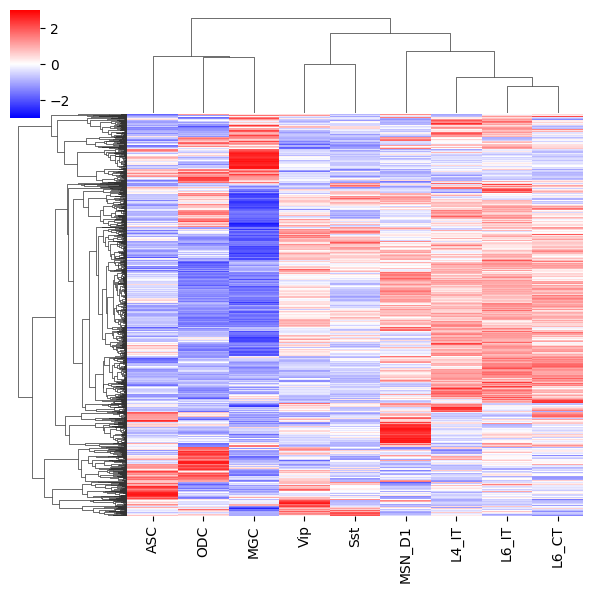

In [19]:
np.random.seed(0)
# sel = np.random.choice(np.arange(len(diffloop)), 2000, False)
cg = sns.clustermap(zscore(diffloop, axis=1), cmap='bwr', 
                    vmin=-3, vmax=3, metric='cosine', 
                    yticklabels=[], xticklabels=1, figsize=(6,6))
rorder = cg.dendrogram_row.reordered_ind.copy()
corder = cg.dendrogram_col.reordered_ind.copy()
leg = diffloop.columns.copy()

findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

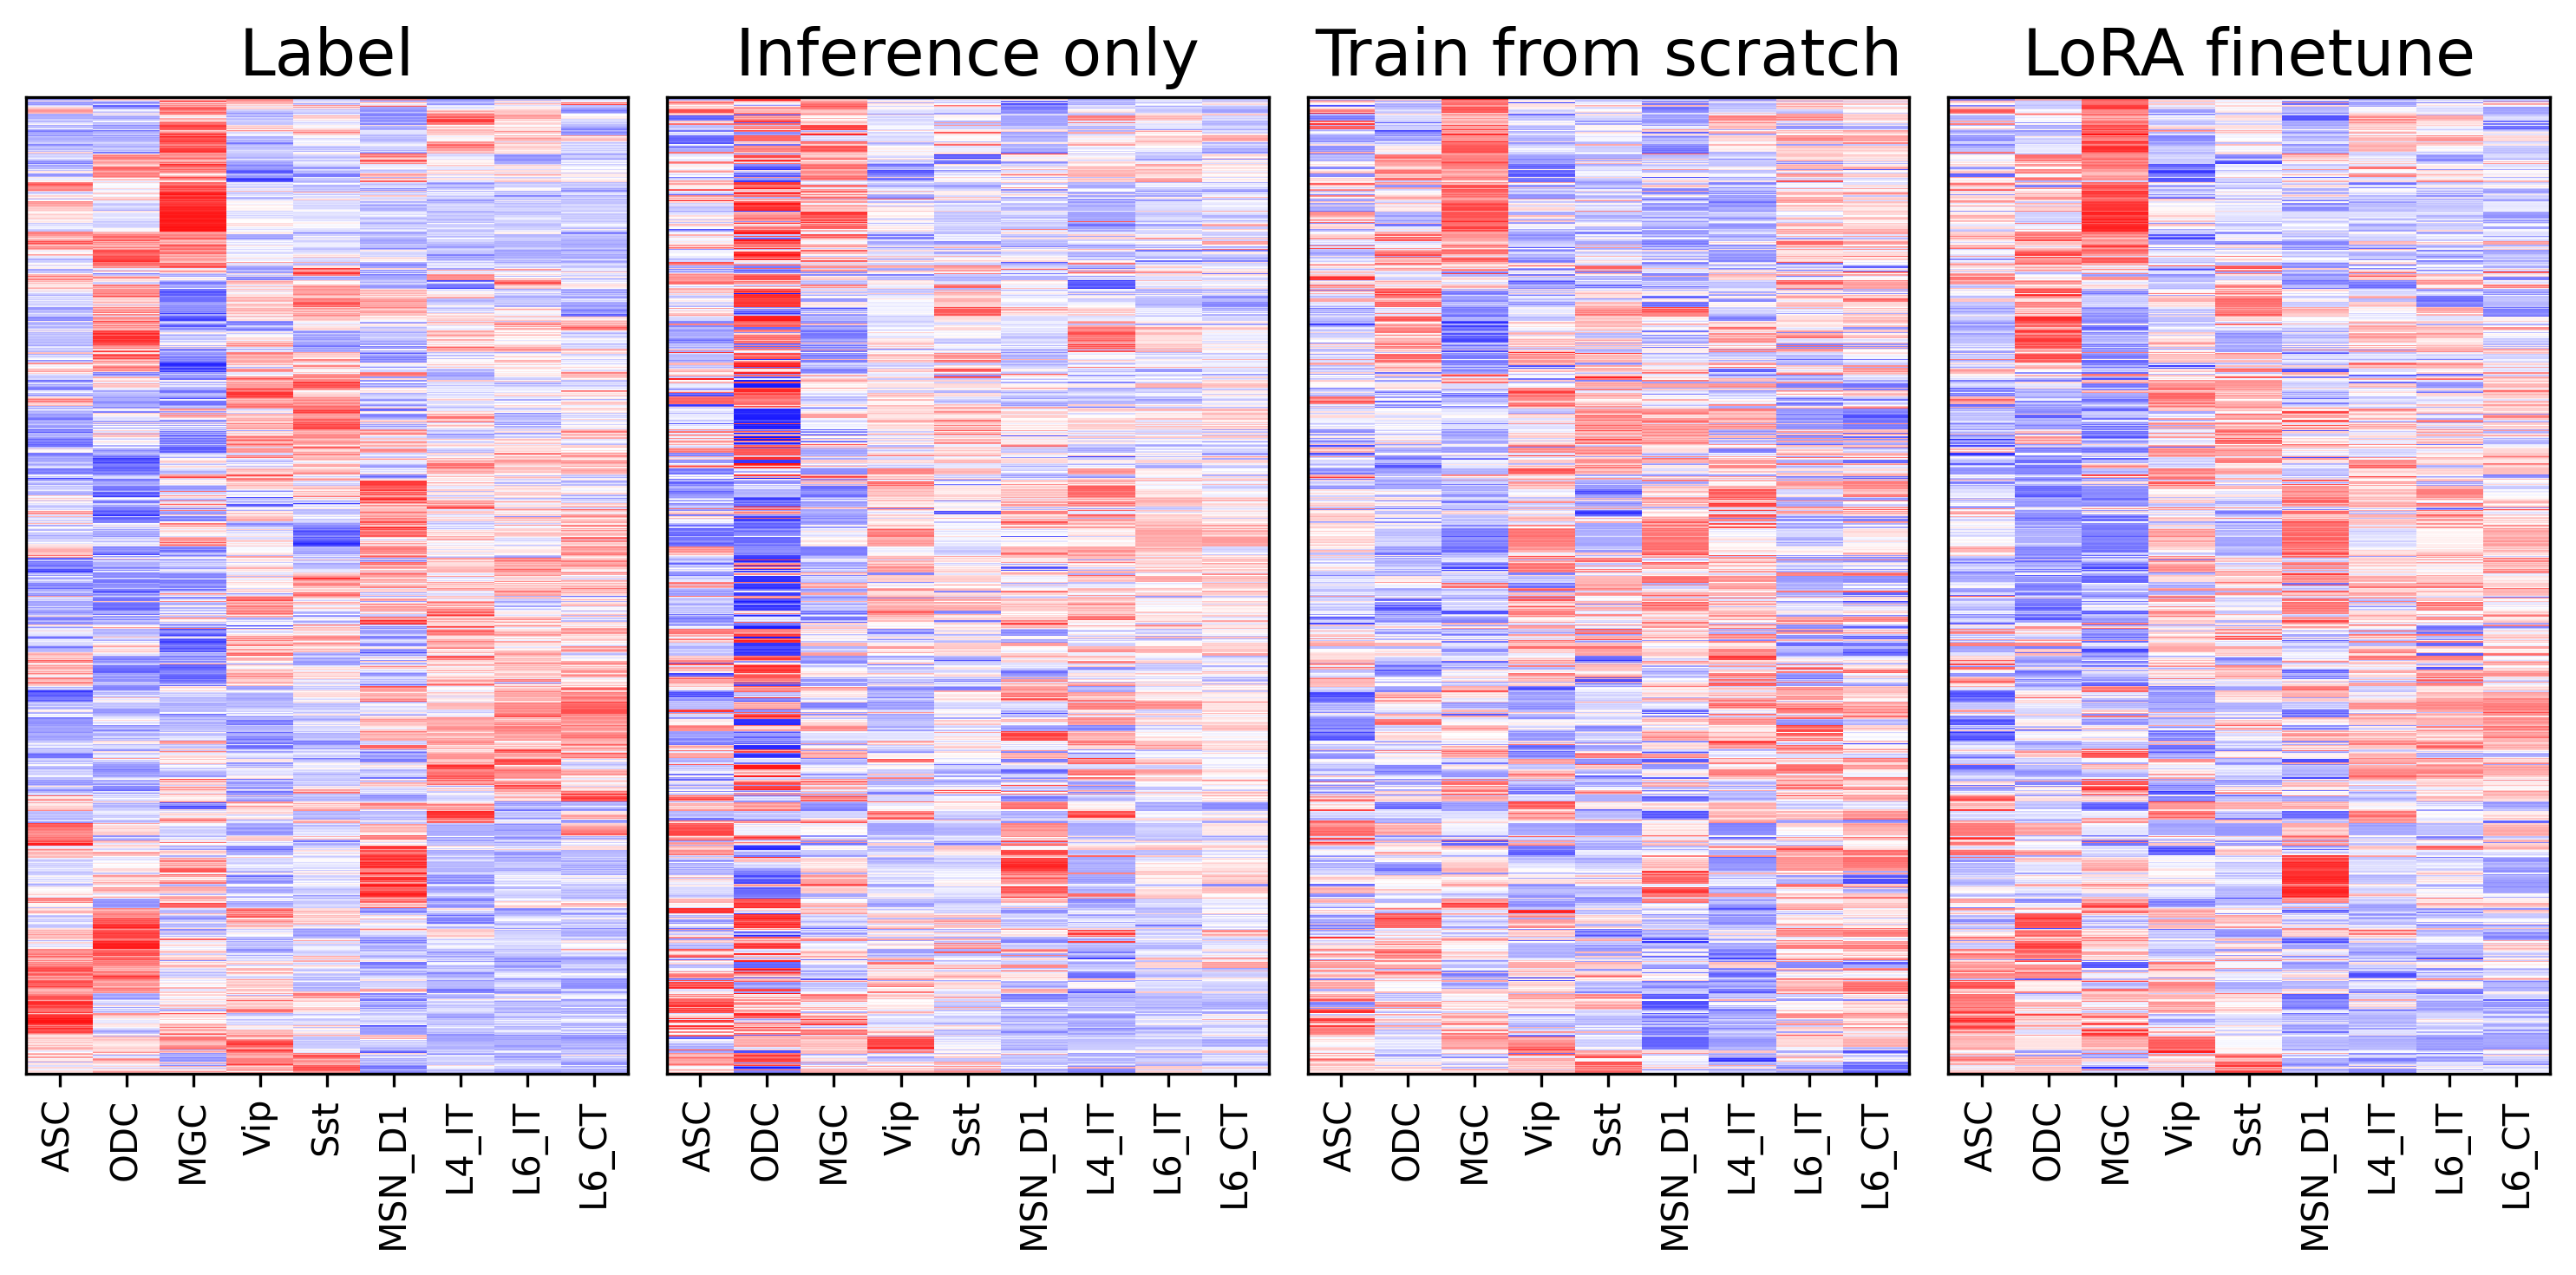

In [20]:
fig, axes = plt.subplots(1, 4, sharey='all', figsize=(10,5), dpi=300)
for i, data in enumerate([diffloop, loop, pretrainloop, loraloop]):
    ax = axes[i]
    ax.imshow(zscore(zscore(data.iloc[rorder,corder], axis=0), axis=1), 
              cmap='bwr', aspect='auto', vmin=-3, vmax=3, interpolation='none')
    ax.set_title(['Label', 'Inference only', 'Train from scratch', 'LoRA finetune'][i], fontsize=18)
    ax.set_xticks(np.arange(len(leg)))
    ax.set_xticklabels(leg[corder], rotation=90)
    ax.set_yticks([])

plt.tight_layout()


findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

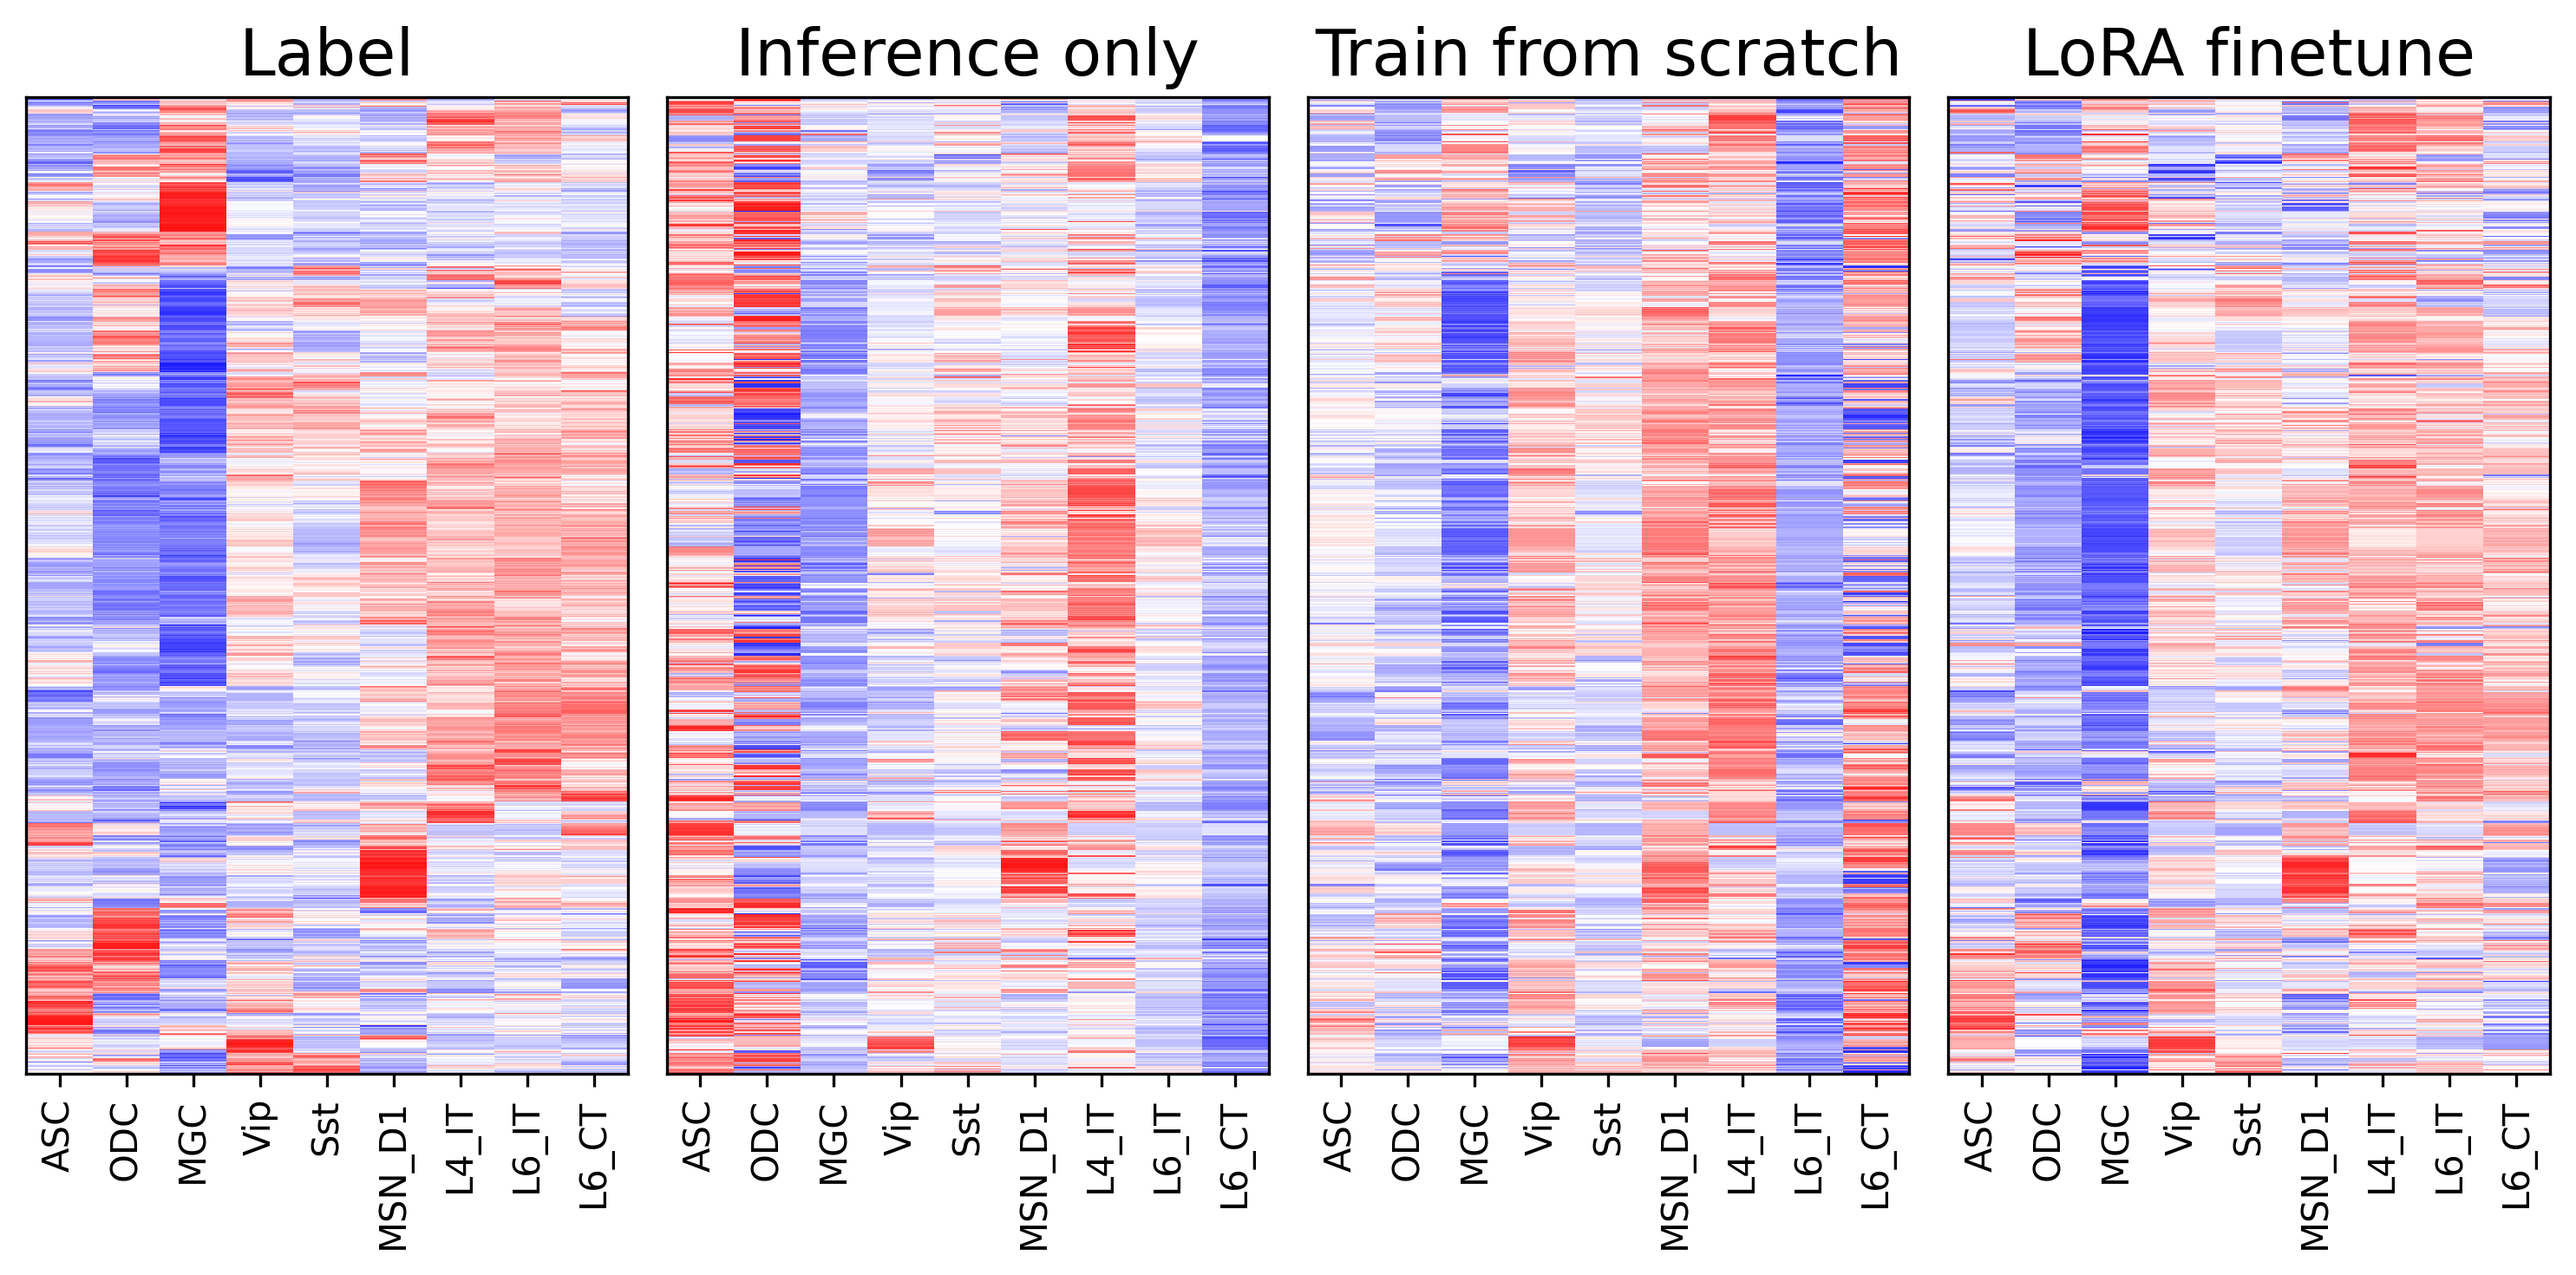

In [23]:
fig, axes = plt.subplots(1, 4, sharey='all', figsize=(10,5), dpi=300)
for i, data in enumerate([diffloop, loop, pretrainloop, loraloop]):
    ax = axes[i]
    ax.imshow(zscore(data.iloc[rorder,corder], axis=1), 
              cmap='bwr', aspect='auto', vmin=-3, vmax=3, interpolation='none')
    ax.set_title(['Label', 'Inference only', 'Train from scratch', 'LoRA finetune'][i], fontsize=18)
    ax.set_xticks(np.arange(len(leg)))
    ax.set_xticklabels(leg[corder], rotation=90)
    ax.set_yticks([])
    
plt.tight_layout()


In [24]:
for ct in celltype_list:
    print(ct, 
          pearsonr(diffloop[ct].values, pretrainloop[ct].values)[0], 
          pearsonr(diffloop[ct].values, loraloop[ct].values)[0],
          pearsonr(diffloop[ct].values, loop[ct].values)[0]),
    

L4_IT 0.3962090737184529 0.4439149763518812 -0.08420046487290787
L6_IT 0.6555600053037319 0.42552358298637966 -0.2132505537379619
L6_CT 0.532816406635781 0.4502253519502144 -0.22247117764846933
Vip 0.2894711836693754 0.31071340519797763 -0.23487812387883
Sst 0.3914115746338711 0.494649424163054 -0.09365497452309791
MSN_D1 0.2935395401275463 0.2948665314683544 -0.18557423784162375
ASC 0.46611048233998204 0.5324979185111559 0.16384563794917856
ODC 0.618373618878927 0.5978992304292359 0.3890056827574213
MGC 0.7394743991305787 0.7046835925448109 -0.04779509991487166


In [25]:
for ct in celltype_list:
    print(ct, 
          pearsonr(zscore(diffloop, axis=1)[ct].values, zscore(pretrainloop, axis=1)[ct].values)[0], 
          pearsonr(zscore(diffloop, axis=1)[ct].values, zscore(loraloop, axis=1)[ct].values)[0],
          pearsonr(zscore(diffloop, axis=1)[ct].values, zscore(loop, axis=1)[ct].values)[0]),
    

L4_IT 0.6201493894144677 0.6591386643002947 0.5270418994264072
L6_IT 0.1428595762615578 0.5859670897376841 0.34272374189892507
L6_CT -0.08551208899050677 0.6541607465759982 0.3855202146824039
Vip 0.6428766834043798 0.7049426945611058 0.5472651574863509
Sst 0.5299476129682887 0.6613337179064938 0.4553542056274538
MSN_D1 0.5038068244422842 0.7303164479826054 0.614420964176027
ASC 0.4702257216065394 0.7329139891401232 0.4477010991011213
ODC 0.549015016986954 0.7532069447940432 0.19547034178753972
MGC 0.726022292404737 0.8347628098253205 0.5561109925087743


In [26]:
np.mean([pearsonr(xx, yy)[0] for xx,yy in zip(diffloop.values, pretrainloop.values)])

0.4128251121867407

In [27]:
np.mean([pearsonr(xx, yy)[0] for xx,yy in zip(diffloop.values, loraloop.values)])

0.7612499321754341

In [28]:
np.mean([pearsonr(xx, yy)[0] for xx,yy in zip(diffloop.values, loop.values)])

0.31747920551567876

In [29]:
np.mean([pearsonr(xx, yy)[0] for xx,yy in zip(zscore(diffloop.values, axis=0), zscore(pretrainloop.values, axis=0))])

0.4670108802691895

In [30]:
np.mean([pearsonr(xx, yy)[0] for xx,yy in zip(zscore(diffloop.values, axis=0), zscore(loraloop.values, axis=0))])

0.6609237806900576

In [31]:
np.mean([pearsonr(xx, yy)[0] for xx,yy in zip(zscore(diffloop.values, axis=0), zscore(loop.values, axis=0))])

0.36167255409512433